# Notebook 2 — Feature Engineering

Rationale for every feature created.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../data/Instagram_Analytics.csv')

## 1. Engagement ratio features

Raw counts (likes, comments) are confounded by reach size. Ratios normalize for audience exposure.

In [2]:
df['total_interactions']     = df['likes'] + df['comments'] + df['shares'] + df['saves']
df['save_rate']              = df['saves'] / (df['reach'] + 1)
df['comment_like_ratio']     = df['comments'] / (df['likes'] + 1)
df['share_rate']             = df['shares'] / (df['reach'] + 1)
df['impression_reach_ratio'] = df['impressions'] / (df['reach'] + 1)
df['virality_score']         = (df['shares'] + df['saves']) / (df['reach'] + 1)
df['engagement_depth']       = df['comments'] / (df['total_interactions'] + 1)
print('Ratio features created.')

Ratio features created.


## 2. Cyclical time encoding

Raw `post_hour` treats 23 and 0 as maximally distant (gap of 23). Sine/cosine encoding wraps the cycle so 23 and 0 are adjacent — more correct for a model learning posting patterns.

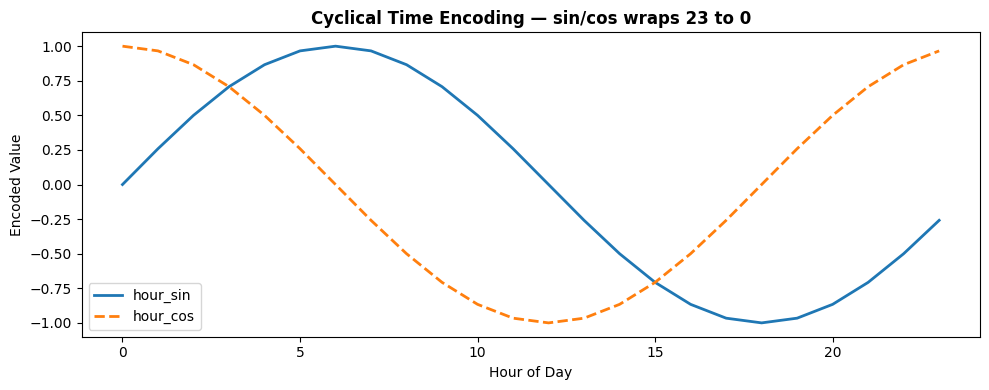

Time features created.


In [3]:
hours = np.arange(24)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, np.sin(2*np.pi*hours/24), label='hour_sin', lw=2)
ax.plot(hours, np.cos(2*np.pi*hours/24), label='hour_cos', lw=2, linestyle='--')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Encoded Value')
ax.set_title('Cyclical Time Encoding — sin/cos wraps 23 to 0', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

df['is_weekend']   = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
df['is_prime_time']= df['post_hour'].between(18,22).astype(int)
df['is_morning']   = df['post_hour'].between(6,10).astype(int)
df['hour_sin']     = np.sin(2*np.pi*df['post_hour']/24)
df['hour_cos']     = np.cos(2*np.pi*df['post_hour']/24)
print('Time features created.')

## 3. Engineered feature distributions by class

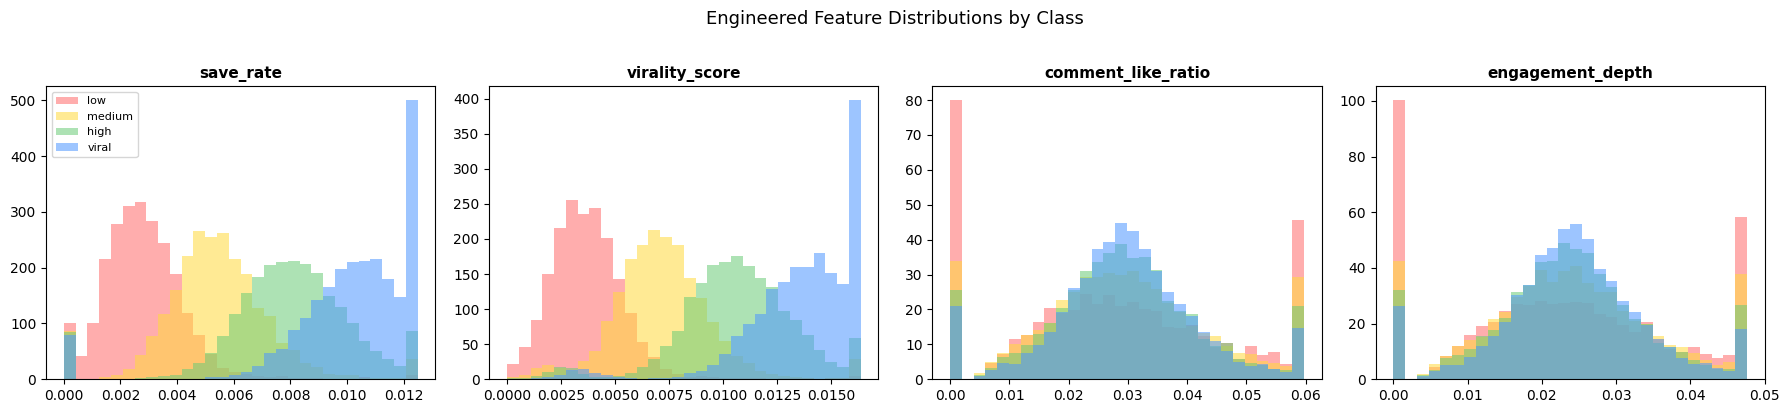

In [4]:
target_map = {'low':0,'medium':1,'high':2,'viral':3}
df['target'] = df['performance_bucket_label'].map(target_map)

new_feats = ['save_rate','virality_score','comment_like_ratio','engagement_depth']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
order = ['low','medium','high','viral']
colors = ['#FF6B6B','#FFD93D','#6BCB77','#4D96FF']
for ax, feat in zip(axes, new_feats):
    cap = df[feat].quantile(0.95)
    for cls, col in zip(order, colors):
        vals = df[df['performance_bucket_label']==cls][feat].clip(upper=cap)
        ax.hist(vals, bins=30, alpha=0.55, label=cls, density=True, color=col)
    ax.set_title(feat, fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
plt.suptitle('Engineered Feature Distributions by Class', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 4. Label encoding for categoricals

In [5]:
le = LabelEncoder()
for col in ['media_type','content_category','traffic_source','account_type','day_of_week']:
    df[col+'_enc'] = le.fit_transform(df[col])
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

media_type: {'carousel': np.int64(0), 'image': np.int64(1), 'reel': np.int64(2)}
content_category: {'Beauty': np.int64(0), 'Comedy': np.int64(1), 'Fashion': np.int64(2), 'Fitness': np.int64(3), 'Food': np.int64(4), 'Lifestyle': np.int64(5), 'Music': np.int64(6), 'Photography': np.int64(7), 'Technology': np.int64(8), 'Travel': np.int64(9)}
traffic_source: {'Explore': np.int64(0), 'External': np.int64(1), 'Hashtags': np.int64(2), 'Home Feed': np.int64(3), 'Profile': np.int64(4), 'Reels Feed': np.int64(5)}
account_type: {'brand': np.int64(0), 'creator': np.int64(1)}
day_of_week: {'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}
